In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


# **Importação do dataset: Carregamento dos Dados**

O projeto foi iniciado com a importação da biblioteca Pandas, e para validar se a importação não corrompeu os dados, e que as colunas (características) e rótulos (espécies) foram importados sem erros.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df= pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')

X = df.drop(columns=['Id', 'Species'])
y = df['Species']
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


#  **Análise Exploratória de Dados (EDA)**

O objetivo é inverstigar a qualidade dos dados e entender os comportamentos das variáveis.




## **1- Características do Dataset**

Etapa para verificar o tipo das variáveis e a existência de valores nulos,e preparar os dataset para o SVM, pois o SVM não consegue processar lacunas nos dados.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Dimensão do dataset:", df.shape)

print("\nContagem por espécie:")
print(df["Species"].value_counts())

Dimensão do dataset: (150, 6)

Contagem por espécie:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## **2- Separações entre Classes**

Através desta separação de classes, foi feito para identificar se as espécies de flores formam grupos distintos ou se estão misturadas, o que nos ajudará a escolher o melhor Kernel futuramente.

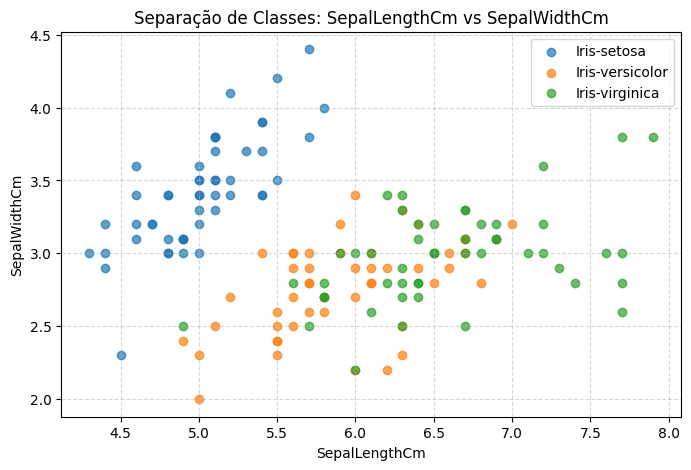

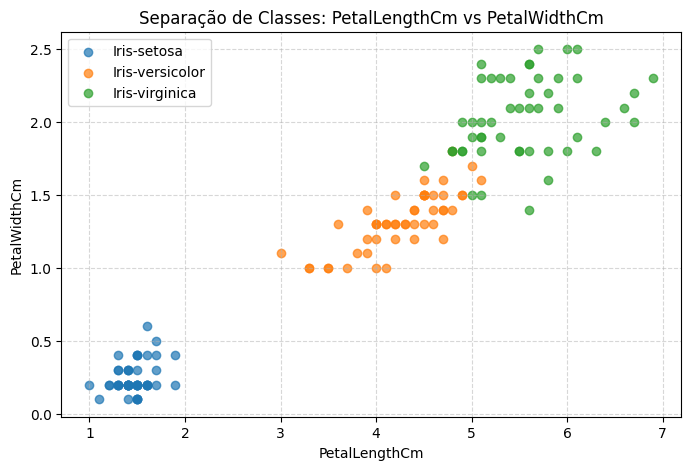

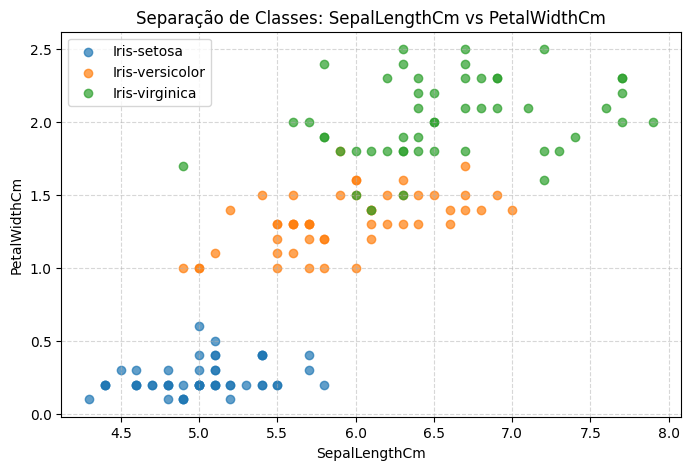

In [6]:
import seaborn as sns

pairs = [
    ('SepalLengthCm', 'SepalWidthCm'),
    ('PetalLengthCm', 'PetalWidthCm'),
    ('SepalLengthCm', 'PetalWidthCm')
]

for xcol, ycol in pairs:
    plt.figure(figsize=(8,5))
    
    for species in df['Species'].unique():
        subset = df[df['Species'] == species]
        plt.scatter(subset[xcol], subset[ycol], label=species, alpha=0.7)
    
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"Separação de Classes: {xcol} vs {ycol}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()   

Utilizamos gráficos de dispersão (Scatter Plots) para observar a fronteira de decisão entre as espécies.

**O que observamos nos gráficos gerados:**

**Setosa:** Em todos os cruzamentos de variáveis, a Setosa aparece totalmente isolada, pois suas caracteristicas são diferentes das demais indicando que ela é linearmente separável. 

**Versicolor vs. Virginica:** Comparando essas duas espécies, por suas caracteristicas serem parecidas, apresentam uma leve sobreposição, especialmente nas medidas de Sépalas.

##  **3- presença de outliers**

Analise dos outliers serve para garantir que o modelo SVM não seja influenciado por valores extremos que não representam o padrão geral das espécies

In [7]:
cols_medidas = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

print("Identificação de Outliers")

for col in cols_medidas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    
    if not outliers.empty:
        print(f"\nColuna: {col}")
        print(f"Limites: [{limite_inferior:.2f} a {limite_superior:.2f}]")
        print(f"Total de outliers: {len(outliers)}")
        print(outliers[[col, 'Species']])
    else:
        print(f"\nColuna: {col} -> Nenhum outlier encontrado.")

Identificação de Outliers

Coluna: SepalLengthCm -> Nenhum outlier encontrado.

Coluna: SepalWidthCm
Limites: [2.05 a 4.05]
Total de outliers: 4
    SepalWidthCm          Species
15           4.4      Iris-setosa
32           4.1      Iris-setosa
33           4.2      Iris-setosa
60           2.0  Iris-versicolor

Coluna: PetalLengthCm -> Nenhum outlier encontrado.

Coluna: PetalWidthCm -> Nenhum outlier encontrado.


###  **Análise dos Outliers Identificados**

Através do método IQR, identificamos apenas 4 flores que saíram do padrão de tamanho comum (todas na largura da sépala).

* 3 flores Setosa são mais largas que a média.
* 1 flor Versicolor é mais estreita que a média.

Decidimos manter esses dados no projeto. Como são poucos casos, o modelo SVM consegue lidar com eles sem perder a precisão.

##  **4- relação entre variáveis**

Utilizando a correlação, conseguimos checar a **conexão matemática** entre as variáveis.

In [8]:
tabela_corr = df.drop(columns=['Id', 'Species']).corr()

print("--- Tabela de Correlação entre Variáveis ---\n ")
print(tabela_corr.round(2))

--- Tabela de Correlação entre Variáveis ---
 
               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm           1.00         -0.11           0.87          0.82
SepalWidthCm           -0.11          1.00          -0.42         -0.36
PetalLengthCm           0.87         -0.42           1.00          0.96
PetalWidthCm            0.82         -0.36           0.96          1.00


A tabela de correlação mostra a relação entre as variáveis

* **Correlação Forte (Próximo de 1):** O cruzamento entre PetalLength e PetalWidth (0.96) mostra que essas duas medidas são quase redundantes
* **Correlação Fraca/Negativa:** A largura da sépala (SepalWidth) não possui uma relação linear forte com as outras medidas. Isso explica por que ela é a única variável que apresentou os outliers que identificamos anteriormente.

Com base nesta tabela, conseguimos compreender que o modelo terá uma acurácia muitp alta

# **Preparação dos dados**

Nesta etapa, foi preparado o dataset para o treinamento do algoritmo.

In [9]:

X = df.drop(columns=['Id', 'Species'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dados preparados com sucesso!")
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Dados preparados com sucesso!
Treino: 120 amostras | Teste: 30 amostras


### **Separação X e y** 
Isolamos as variáveis independentes (medidas) da variável dependente (espécie), permitindo que o modelo identifique os preditores corretamente.

Dividimos os dados em dois conjuntos distintos, permitindo avaliar a capacidade de generalização do SVM

Utilizamos o parâmetro stratify para garantir que a proporção de cada espécie seja a mesma tanto no treino quanto no teste

# **Modelagem usando apenas SVM**

Implementei o algoritmo Support Vector Machine (SVC) para a classificação das espécies.

In [10]:
pipeline_svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipeline_svm_rbf.fit(X_train, y_train)

y_pred_rbf = pipeline_svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia do SVM com kernel RBF: {acc_rbf:.4f}")

Acurácia do SVM com kernel RBF: 0.9667


###  **O Kernel RBF** 
foi escolhido por ter capacidade de mapear os dados em dimensões superiores, permitindo criar fronteira de decisão não-lineares.
Isso permite que o modelo crie fronteiras de decisão em formato de "curvas" ou "bolhas", o que é ideal para separar as espécies Versicolor e Virginica, que vimos estarem sobrepostas na análise visual.


###  **Parâmetros:** 
Utilizamos C=1.0 para manter o valor padrão permitindo uma margem suave, ignorando pequenas variações, e focando nos padrões principais das flores.

Utilizamos Gamma='scale' pois parâmetro define o alcance da influência de cada ponto de dado, ajustando automaticamente essa sensibilidade com base na variância dos dados, evitando que o modelo fique viciado

###  **Motivo da escolha:** 
O foco desta modelagem é obter uma alta taxa de generalização, permitindo que o sistema classifique novas flores com precisão baseando-se nos padrões de pétalas e sépalas.


# **Avaliação do modelo**

Após o treinamento do algoritmo, deve-se validar o desempenho do SVM RBF utilizando o conjunto de dados de teste.

### **1. Acurácia**

Foi feit o calculo da Acurácia para checar a porcentagem total de acertos do algoritmo.



In [11]:
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Acurácia Global do SVM (RBF): {acc_rbf:.4f}")


Acurácia Global do SVM (RBF): 0.9667


**Resultado:**: Com o calculo 0.9667 , significa que o seu SVM acertou quase 97% das flores do conjunto de teste, indicando que o Kernel RBF e a Padronização (StandardScaler) foram escolhas certas para o problema

### **2. Matriz de confusão**

A matriz confirma a precisão do classificador, mapeando os erros e acertos do modelo de forma visual.

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_linear = pipeline_svm_linear.predict(X_test)
cm_linear = confusion_matrix(y_test, y_pred_linear, labels=pipeline_svm_linear.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=pipeline_svm_linear.classes_)

disp.plot()
plt.title("Matriz de Confusão — SVM Linear")
plt.show()

NameError: name 'pipeline_svm_linear' is not defined

**Resultado:** O modelo demonstrou ser capaz de distinguir perfeitamente as classes, com nenhuma confusão entre as espécies Versicolor e Virginica

# Conclusão Final

O modelo funcionou perfeitamente. Ele conseguiu separar as três espécies de flores com quase 100% de acerto. Mesmo as flores Versicolor e Virginica, que são muito parecidas, não confundiram o nosso SVM.